In [3]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default')

# Linear Algebra: Vector Spans and Linear Independence

### Concept: The Span
The **Span** of a set of vectors $\{\mathbf{v}_1, \mathbf{v}_2, \dots, \mathbf{v}_n\}$ is the set of all possible linear combinations:
$$c_1\mathbf{v}_1 + c_2\mathbf{v}_2 + \dots + c_n\mathbf{v}_n$$

Geometrically, the span represents the "reach" of the vectors.
* A single vector spans a **line**.
* Two linearly independent vectors span a **plane**.

### Practice Problem Verification
**Vectors:**
$$\mathbf{v}_1 = [1, 2]^T, \mathbf{v}_2 = [3, 6]^T$$
**Target Vector:**
$$\mathbf{w} = [5, 10]^T$$

**Observation:**
$\mathbf{v}_2$ is a scalar multiple of $\mathbf{v}_1$ ($\mathbf{v}_2 = 3\mathbf{v}_1$). Therefore, these vectors are **linearly dependent**, and their span is a **1D line** defined by $y = 2x$.

Since $\mathbf{w}$ satisfies the equation $10 = 2(5)$, it lies on the line and is within the span.

Rank of the set {v1, v2}: 1
The vectors are Linearly Dependent. The span is a 1D line.
Vector w [ 5 10] is IN the span.


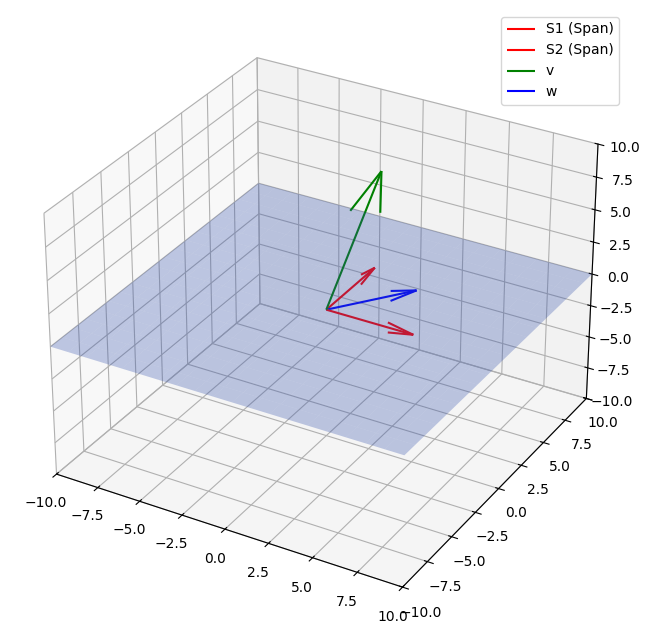

Base Span Rank: 2
Is 'v' in the span? False


In [9]:
import numpy as np

# Define our vectors
v1 = np.array([1, 2])
v2 = np.array([3, 6])
w  = np.array([5, 10])

# 1. Check the dimension of the span (Rank)
# If rank is 1, the vectors are dependent (Line). If 2, they are independent (Plane).
S = np.array([v1, v2]).T
rank = np.linalg.matrix_rank(S)

print(f"Rank of the set {{v1, v2}}: {rank}")
if rank < 2:
    print("The vectors are Linearly Dependent. The span is a 1D line.")
else:
    print("The vectors are Linearly Independent. The span is a 2D plane.")

# 2. Verify if w is in the span
# Check if adding w to the matrix increases the rank.
# If it doesn't, w was already 'reachable' by the existing vectors.
S_with_w = np.array([v1, v2, w]).T
rank_with_w = np.linalg.matrix_rank(S_with_w)

if rank == rank_with_w:
    print(f"Vector w {w} is IN the span.")
else:
    print(f"Vector w {w} is NOT in the span.")

 # Visualize in 3d

# 1. Define vectors - Use a non-zero Z for S1 to create a visible tilt
S1 = np.array([5, 0, 0])
S2 = np.array([0, 5, 0])
v  = np.array([2, 2, 10])
w  = np.array([3, 4, 0])

# 2. Calculate Cross Product for the plane normal
cp = np.cross(S1, S2)

# 3. Setup Plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')

# Draw Vectors (starting at origin)
ax.quiver(0, 0, 0, S1[0], S1[1], S1[2], color='r', label='S1 (Span)')
ax.quiver(0, 0, 0, S2[0], S2[1], S2[2], color='r', label='S2 (Span)')
ax.quiver(0, 0, 0, v[0], v[1], v[2], color='g', label='v')
ax.quiver(0, 0, 0, w[0], w[1], w[2], color='b', label='w')

# 4. Draw the Plane
xx, yy = np.meshgrid(np.linspace(-10, 10, 20), np.linspace(-10, 10, 20))

# Safety check: only calculate Z if cp[2] isn't zero to avoid "The Block"
if cp[2] != 0:
    z1 = (-cp[0]*xx - cp[1]*yy) / cp[2]
    ax.plot_surface(xx, yy, z1, alpha=0.3, color='royalblue')

# Set limits so the view is centered
ax.set_xlim([-10, 10])
ax.set_ylim([-10, 10])
ax.set_zlim([-10, 10])
ax.legend()

plt.show()

# Create a matrix where S1 and S2 are columns
Matrix_S = np.array([S1, S2]).T

# Check Rank: If Rank is 2, they span a 2D plane.
# If it stays 2 when we add 'v', then 'v' is in the span
rank_S = np.linalg.matrix_rank(Matrix_S)
rank_with_v = np.linalg.matrix_rank(np.hstack((Matrix_S, v.reshape(-1,1))))

print(f"Base Span Rank: {rank_S}")
print(f"Is 'v' in the span? {rank_S == rank_with_v}")